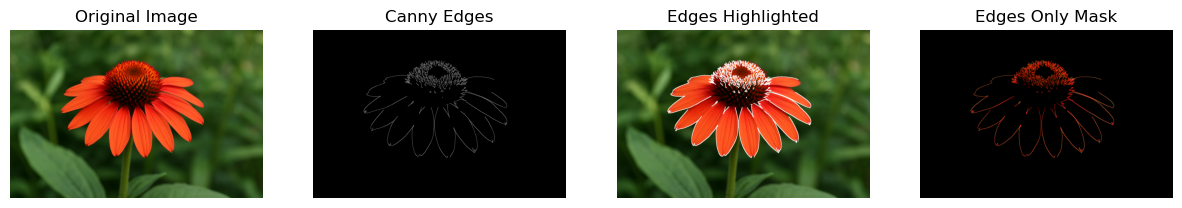

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def edge_based_mask(image_path):
    # Load image in grayscale for edge detection
    img = cv2.imread(image_path)
    if img is None:
        raise Exception("Image not found.")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Canny edge detector
    edges = cv2.Canny(img_gray, threshold1=100, threshold2=200)

    # Dilate edges to make mask thicker / connected
    kernel = np.ones((3,3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)

    # Create a mask where edges are white and rest is black
    mask = edges_dilated.astype(bool)

    # Use mask to highlight edges on original image (white edges)
    highlighted = img_rgb.copy()
    highlighted[mask] = [255, 255, 255]  # Paint edges white

    # Alternatively, create masked image (edges only)
    edges_only = np.zeros_like(img_rgb)
    edges_only[mask] = img_rgb[mask]

    # Plot the results
    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Canny Edges")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(highlighted)
    plt.title("Edges Highlighted")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(edges_only)
    plt.title("Edges Only Mask")
    plt.axis("off")

    plt.savefig("output_edge_based_mask.png")
    plt.show()

if __name__ == "__main__":
    image_path = "img.png"  # Change this to your image path
    edge_based_mask(image_path)
